# A-Phase (AAA Combined): Building and Evaluating the First Recommendation Models

This notebook combines the three A-phases of the QUAAACK workflow for the Movie Recommendation App: **A1 (Algorithm Selection)**, **A2 (Adapt Features)**, and **A3 (Adjust and Assess)**. In the Q-Phase, the project defined the recommendation problem and success criteria. In the U-Phase, it verified the structure, quality, sparsity, and constraints of the `ml-25m` dataset. The purpose of this notebook is to turn that foundation into working recommendation models and a defensible v1 model choice for the Streamlit app.

The notebook is written as a practical model-development and evaluation workflow, not just a theory discussion. It implements required baselines, builds stronger candidate recommenders, uses leakage-aware chronological splitting, tunes a small set of impactful hyperparameters with ranking metrics, and produces examples that show how recommendations can be explained to users.

Because the dataset is large, the notebook includes a **runtime-safe sampled workflow** by default so it can be run interactively on a typical laptop. The sampling strategy is documented and reproducible, and the design keeps the path open for larger offline runs later without changing the evaluation logic.


## How to Read This Notebook (Prose-First AAA Structure)

This is a combined AAA notebook, so it covers three different types of decisions in one place. The first part (A1) compares recommender families and baselines. The second part (A2) documents the feature and split decisions that make the comparisons fair and practical. The third part (A3) tunes a small hyperparameter space and evaluates the candidate models using ranking metrics that match the Streamlit user experience.

To follow the project writing rules, the notebook uses **natural-language paragraphs** for most interpretation and tradeoff discussion. Short lists appear only where the task explicitly requires named methods, metrics, or artifacts. Tables and diagrams are followed by plain-language explanations that describe what they show and why they matter for recommendation quality, explainability, or app responsiveness.


## AAA Roadmap and Offline Evaluation Flow

```text
A1 (Algorithm Selection)
   -> establish baselines and candidate recommender families
   -> define what "better" means (ranking quality + speed + explainability)

A2 (Adapt Features)
   -> encode features available at inference time
   -> implement chronological holdout and leakage checks
   -> define cold-start and candidate generation rules

A3 (Adjust and Assess)
   -> tune a small hyperparameter space using validation ranking metrics
   -> compare candidates on held-out data
   -> prepare explainability examples and export plan for Streamlit
```

```text
Offline evaluation flow used in this notebook

Raw ratings/movies  ->  filtering + chronological split  ->  Train artifacts
                                                       |       (popularity, genre features,
                                                       |        collaborative item-item data)
                                                       v
                                               Validation tuning (ranking metrics)
                                                       v
                                               Candidate comparison + segment analysis
                                                       v
                                               Streamlit v1 ship recommendation + export plan
```

These diagrams show how the combined AAA notebook stays organized even though it covers model selection, feature preparation, and evaluation in one file. The first diagram explains the three A-subphases conceptually, and the second shows the practical sequence used in code. This matters because it keeps the notebook readable for non-technical reviewers while still documenting the full modeling workflow.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import random
import time
from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook requires numpy, pandas, and matplotlib. "
        "Install them in the notebook environment before running A-Phase."
    ) from exc

try:
    from IPython.display import display
except ModuleNotFoundError:
    # Fallback for non-notebook execution
    def display(x):
        print(x)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path('ml-25m')
ARTIFACTS_DIR = Path('artifacts')

plt.style.use('ggplot')

CONFIG = {
    'seed': SEED,
    'k': 10,
    'relevance_threshold': 4.0,
    'val_holdout': 1,
    'test_holdout': 1,
    'min_train_interactions_after_split': 5,
    'sample_max_users': 1200,   # runtime-safe default; set None for all eligible users
    'sample_user_strategy': 'random_eligible',
    'max_ratings_rows': None,    # optional early cap for debugging only (None recommended)
    'load_tags_for_optional_prep_demo': False,
    'content_profile_min_rating': 4.0,
    'content_candidate_limit_default': 1200,  # cap content candidate scores per user for notebook runtime
    'genre_pref_top_n_default': 2,
    'pop_min_count_default': 20,
    'cf_positive_threshold': 4.0,
    'cf_min_item_interactions': 20,
    'cf_max_items': 2000,        # caps collaborative matrix size for notebook runtime
    'cf_top_neighbors_default': 50,
    'tune_user_limit': 400,      # validation users used during hyperparameter tuning
    'segment_split_quantile': 0.5,
}

TUNING_GRID = {
    'cf_top_neighbors': [20, 50, 100],
    'hybrid_alpha': [0.4, 0.6, 0.8],
    'genre_pref_top_n': [1, 2, 3],
}

print('A-Phase configuration loaded.')
print(json.dumps(CONFIG, indent=2))
print('Tuning grid sizes:', {k: len(v) for k, v in TUNING_GRID.items()})


A-Phase configuration loaded.
{
  "seed": 42,
  "k": 10,
  "relevance_threshold": 4.0,
  "val_holdout": 1,
  "test_holdout": 1,
  "min_train_interactions_after_split": 5,
  "sample_max_users": 1200,
  "sample_user_strategy": "random_eligible",
  "max_ratings_rows": null,
  "load_tags_for_optional_prep_demo": false,
  "content_profile_min_rating": 4.0,
  "content_candidate_limit_default": 1200,
  "genre_pref_top_n_default": 2,
  "pop_min_count_default": 20,
  "cf_positive_threshold": 4.0,
  "cf_min_item_interactions": 20,
  "cf_max_items": 2000,
  "cf_top_neighbors_default": 50,
  "tune_user_limit": 400,
  "segment_split_quantile": 0.5
}
Tuning grid sizes: {'cf_top_neighbors': 3, 'hybrid_alpha': 3, 'genre_pref_top_n': 3}


The setup cell defines a reproducible configuration and a small hyperparameter grid that is suitable for notebook iteration. The defaults intentionally favor a sampled workflow because the goal of this notebook is to compare recommendation strategies and document a v1 decision, not to perform an hours-long training run in an interactive environment.

This configuration design also supports the project architecture decision to keep heavy work offline. The same evaluation functions and model logic can be reused later with larger limits or batch pipelines, while the Streamlit app remains focused on loading precomputed artifacts.


## A1 - Algorithm Selection: Loading Data and Defining the Modeling Workspace

The first step in algorithm selection is to establish a clean and reproducible modeling workspace. In this notebook, the core modeling path uses `ratings.csv` and `movies.csv`, which the U-Phase identified as sufficient for a strong v1 baseline and candidate comparison. Optional sources such as `tags.csv` and genome features are acknowledged, but they are treated as deferred or experimental unless they produce a clear quality gain relative to their runtime and complexity cost.

The code below loads the core data, parses timestamps, extracts movie release years, and builds genre lists that will be reused across the content-based, genre-popularity, and hybrid recommenders.


In [2]:
RATINGS_DTYPES = {
    'userId': 'int32',
    'movieId': 'int32',
    'rating': 'float32',
    'timestamp': 'int64',
}
MOVIES_DTYPES = {
    'movieId': 'int32',
    'title': 'string',
    'genres': 'string',
}
TAGS_DTYPES = {
    'userId': 'int32',
    'movieId': 'int32',
    'tag': 'string',
    'timestamp': 'int64',
}

ratings_df = pd.read_csv(DATA_DIR / 'ratings.csv', dtype=RATINGS_DTYPES)
movies_df = pd.read_csv(DATA_DIR / 'movies.csv', dtype=MOVIES_DTYPES)

if CONFIG['max_ratings_rows']:
    ratings_df = ratings_df.head(int(CONFIG['max_ratings_rows'])).copy()

ratings_df['timestamp_dt'] = pd.to_datetime(ratings_df['timestamp'], unit='s', utc=True, errors='coerce')
movies_df['genres'] = movies_df['genres'].fillna('(no genres listed)').astype('string')
movies_df['year'] = (
    movies_df['title']
    .astype('string')
    .str.extract(r'\((\d{4})\)\s*$', expand=False)
    .astype('Int64')
)
movies_df['genre_list'] = (
    movies_df['genres']
    .astype('string')
    .str.split(r'\|')
    .apply(lambda x: x if isinstance(x, list) else ['(no genres listed)'])
)

movie_meta_df = movies_df[['movieId', 'title', 'year', 'genres']].copy()
movie_meta_df = movie_meta_df.drop_duplicates(subset=['movieId']).set_index('movieId')

optional_tags_status = 'not loaded (deferred by default for runtime)' 
if CONFIG['load_tags_for_optional_prep_demo']:
    tags_df = pd.read_csv(DATA_DIR / 'tags.csv', dtype=TAGS_DTYPES)
    tags_df['timestamp_dt'] = pd.to_datetime(tags_df['timestamp'], unit='s', utc=True, errors='coerce')
    optional_tags_status = f'loaded: {len(tags_df):,} rows'

load_summary_df = pd.DataFrame([
    {'dataset': 'ratings.csv', 'rows': len(ratings_df), 'columns': list(ratings_df.columns), 'notes': 'Core interactions'},
    {'dataset': 'movies.csv', 'rows': len(movies_df), 'columns': list(movies_df.columns), 'notes': 'Core metadata'},
    {'dataset': 'tags.csv', 'rows': np.nan if not CONFIG['load_tags_for_optional_prep_demo'] else len(tags_df), 'columns': [] if not CONFIG['load_tags_for_optional_prep_demo'] else list(tags_df.columns), 'notes': optional_tags_status},
])
display(load_summary_df)

print('Ratings time range (parsed):', ratings_df['timestamp_dt'].min(), '->', ratings_df['timestamp_dt'].max())
print('Unique users in raw ratings:', f"{ratings_df['userId'].nunique():,}")
print('Unique movies in raw ratings:', f"{ratings_df['movieId'].nunique():,}")


,dataset,rows,columns,notes
0,ratings.csv,25000095.0,"[userId, movieId, rating, timestamp, timestamp...",Core interactions
1,movies.csv,62423.0,"[movieId, title, genres, year, genre_list]",Core metadata
2,tags.csv,NaN,[],not loaded (deferred by default for runtime)


Ratings time range (parsed): 1995-01-09 11:46:49+00:00 -> 2019-11-21 09:15:03+00:00
Unique users in raw ratings: 162,541
Unique movies in raw ratings: 59,047


The loading summary confirms that the modeling notebook starts from the same core data path defined in the earlier phases: `ratings.csv` for interactions and `movies.csv` for metadata. The optional tags file is explicitly handled as a deferred enrichment path by default so the notebook remains fast enough to iterate on without hiding that tradeoff.

This table and the printed time range matter for algorithm selection because they establish what signals are available for chronological evaluation and which feature sources can be included in a realistic Streamlit v1 without unnecessary runtime cost.


## A2 - Adapt Features: Chronological Split, Filtering, and Leakage Controls

Before comparing models, we need to define a leakage-safe evaluation setup. Following `DATA.md` and the accepted project decisions, this notebook uses a **per-user chronological holdout**: earlier interactions go to training, and the most recent interactions are reserved for validation and test. This mirrors the product scenario more closely than a random split.

The next cell also applies a reproducible user sampling strategy for notebook runtime and enforces a minimum number of training interactions after holdout. Those filters are documented so the AAA results remain interpretable rather than appearing as unexplained score changes.


In [3]:
def build_chronological_split(ratings: pd.DataFrame, config: dict) -> dict:
    rel_threshold = float(config['relevance_threshold'])
    val_holdout = int(config['val_holdout'])
    test_holdout = int(config['test_holdout'])
    min_train_after_split = int(config['min_train_interactions_after_split'])
    min_total_needed = val_holdout + test_holdout + min_train_after_split

    ratings = ratings.dropna(subset=['timestamp_dt']).copy()
    ratings = ratings[ratings['movieId'].isin(movies_df['movieId'])].copy()

    user_total_counts = ratings.groupby('userId').size().rename('total_interactions')
    eligible_users = user_total_counts[user_total_counts >= min_total_needed].index.to_numpy()

    rng = np.random.default_rng(int(config['seed']))
    if config['sample_max_users'] is not None and len(eligible_users) > int(config['sample_max_users']):
        sampled_users = rng.choice(eligible_users, size=int(config['sample_max_users']), replace=False)
    else:
        sampled_users = eligible_users

    sampled_users = np.sort(sampled_users)
    ratings_work = ratings[ratings['userId'].isin(sampled_users)].copy()
    ratings_work = ratings_work.sort_values(['userId', 'timestamp', 'movieId']).reset_index(drop=True)

    ratings_work['pos_asc'] = ratings_work.groupby('userId').cumcount()
    ratings_work['n_user'] = ratings_work.groupby('userId')['movieId'].transform('size').astype('int32')
    ratings_work['pos_desc'] = (ratings_work['n_user'] - 1 - ratings_work['pos_asc']).astype('int32')

    test_mask = ratings_work['pos_desc'] < test_holdout
    val_mask = (ratings_work['pos_desc'] >= test_holdout) & (ratings_work['pos_desc'] < (test_holdout + val_holdout))
    train_mask = ratings_work['pos_desc'] >= (test_holdout + val_holdout)

    train_df = ratings_work.loc[train_mask].copy()
    val_df = ratings_work.loc[val_mask].copy()
    test_df = ratings_work.loc[test_mask].copy()

    train_counts = train_df.groupby('userId').size().rename('train_interactions')
    valid_users = train_counts[train_counts >= min_train_after_split].index

    train_df = train_df[train_df['userId'].isin(valid_users)].copy()
    val_df = val_df[val_df['userId'].isin(valid_users)].copy()
    test_df = test_df[test_df['userId'].isin(valid_users)].copy()

    # Mark relevance for ranking evaluation
    train_df['is_relevant'] = (train_df['rating'] >= rel_threshold)
    val_df['is_relevant'] = (val_df['rating'] >= rel_threshold)
    test_df['is_relevant'] = (test_df['rating'] >= rel_threshold)

    # Leakage checks: latest train <= earliest val/test for each user
    train_max = train_df.groupby('userId')['timestamp'].max().rename('train_max_ts')
    val_min = val_df.groupby('userId')['timestamp'].min().rename('val_min_ts')
    test_min = test_df.groupby('userId')['timestamp'].min().rename('test_min_ts')
    leakage_df = pd.concat([train_max, val_min, test_min], axis=1)
    leakage_df['train_before_val'] = leakage_df['train_max_ts'] <= leakage_df['val_min_ts']
    leakage_df['train_before_test'] = leakage_df['train_max_ts'] <= leakage_df['test_min_ts']

    return {
        'train': train_df,
        'val': val_df,
        'test': test_df,
        'sampled_users': sampled_users,
        'eligible_user_count_before_sampling': int(len(eligible_users)),
        'leakage_checks': leakage_df,
        'min_total_needed': min_total_needed,
    }

split_data = build_chronological_split(ratings_df, CONFIG)
train_ratings_df = split_data['train']
val_ratings_df = split_data['val']
test_ratings_df = split_data['test']
leakage_checks_df = split_data['leakage_checks']

split_summary_df = pd.DataFrame([
    {'split': 'train', 'rows': len(train_ratings_df), 'users': train_ratings_df['userId'].nunique(), 'movies': train_ratings_df['movieId'].nunique(), 'relevant_rows': int(train_ratings_df['is_relevant'].sum())},
    {'split': 'val', 'rows': len(val_ratings_df), 'users': val_ratings_df['userId'].nunique(), 'movies': val_ratings_df['movieId'].nunique(), 'relevant_rows': int(val_ratings_df['is_relevant'].sum())},
    {'split': 'test', 'rows': len(test_ratings_df), 'users': test_ratings_df['userId'].nunique(), 'movies': test_ratings_df['movieId'].nunique(), 'relevant_rows': int(test_ratings_df['is_relevant'].sum())},
])

display(split_summary_df)

filtering_summary_df = pd.DataFrame([
    {'metric': 'Eligible users before sampling', 'value': split_data['eligible_user_count_before_sampling']},
    {'metric': 'Sampled users used in AAA notebook', 'value': int(len(split_data['sampled_users']))},
    {'metric': 'Minimum total interactions required before split', 'value': int(split_data['min_total_needed'])},
    {'metric': 'Minimum train interactions required after split', 'value': int(CONFIG['min_train_interactions_after_split'])},
])
display(filtering_summary_df)

leakage_summary_df = pd.DataFrame([
    {'check': 'Users with train timestamp <= validation timestamp', 'pass_rate': float(leakage_checks_df['train_before_val'].dropna().mean())},
    {'check': 'Users with train timestamp <= test timestamp', 'pass_rate': float(leakage_checks_df['train_before_test'].dropna().mean())},
])
display(leakage_summary_df)


,split,rows,users,movies,relevant_rows
0,train,194459,1200,13658,97150
1,val,1200,1200,895,690
2,test,1200,1200,908,720


,metric,value
0,Eligible users before sampling,162541
1,Sampled users used in AAA notebook,1200
2,Minimum total interactions required before split,7
3,Minimum train interactions required after split,5


,check,pass_rate
0,Users with train timestamp <= validation times...,1.0
1,Users with train timestamp <= test timestamp,1.0


The split summary table shows how many rows, users, and movies end up in each split after filtering and chronological holdout. The filtering summary documents the runtime-safe sampling and minimum interaction thresholds, which is important because these choices directly affect difficulty and runtime. The leakage check table then verifies the key time-ordering assumption for evaluation.

This set of tables matters because ranking scores are only meaningful if the split is both realistic and reproducible. Without explicit holdout logic and timestamp checks, a recommender can appear stronger than it really is due to hidden leakage or inconsistent user filtering.


## A2 - Feature Preparation and Candidate Generation Rules

The next cells build the shared artifacts used by multiple recommenders. This is where the notebook documents the practical feature choices for v1: genre encoding from `movies.csv`, popularity tables from training data only, and a lightweight collaborative item-item representation built from training interactions. Optional tag and genome features are described later as deferred enhancements because the project currently prioritizes explainability and notebook/app runtime.

The feature work also defines the candidate generation rules used during evaluation. These rules ensure that recommendation functions exclude items already seen in training and rely only on train-time statistics, which keeps the comparisons leakage-safe.


In explicit A2 terms, this notebook implements **genre encoding**, documents **tag preprocessing** as an optional deferred step for v1 (required before tags are used in a model), applies a practical **rating normalization** strategy inside the recommenders (for example rating-based weights such as `rating - 2.5` in profile and collaborative scoring), and records the minimum user/item interaction thresholds that constrain candidate generation and collaborative coverage.


In [4]:
# Shared lookup maps and train-only aggregates used by all recommenders
K = int(CONFIG['k'])
REL_THRESHOLD = float(CONFIG['relevance_threshold'])

# Metadata lookups
movie_title_map = movie_meta_df['title'].to_dict()
movie_year_map = movie_meta_df['year'].to_dict()
movie_genres_map = movie_meta_df['genres'].to_dict()
movie_genre_list_map = movies_df.set_index('movieId')['genre_list'].to_dict()

# Train interactions and user history maps
train_catalog_movie_ids = np.sort(train_ratings_df['movieId'].unique())
train_catalog_set = set(train_catalog_movie_ids.tolist())
all_movie_ids = movies_df['movieId'].to_numpy()
all_movie_set = set(all_movie_ids.tolist())

user_train_history = train_ratings_df.sort_values(['userId', 'timestamp', 'movieId']).groupby('userId')
user_seen_train_items = user_train_history['movieId'].apply(list).to_dict()
user_seen_train_sets = {u: set(items) for u, items in user_seen_train_items.items()}
user_train_positive_items = (
    train_ratings_df[train_ratings_df['rating'] >= REL_THRESHOLD]
    .sort_values(['userId', 'rating', 'timestamp'], ascending=[True, False, False])
    .groupby('userId')['movieId']
    .apply(list)
    .to_dict()
)
user_train_counts = train_ratings_df.groupby('userId').size().rename('train_interaction_count')
user_train_mean_rating = train_ratings_df.groupby('userId')['rating'].mean().rename('train_mean_rating')

# Genre one-hot encoding (A2 requirement: encode genres)
genre_feature_df = movies_df[['movieId']].copy()
genre_dummies = movies_df['genres'].str.get_dummies(sep='|').astype('float32')
genre_feature_df = pd.concat([genre_feature_df, genre_dummies], axis=1)

genre_feature_cols = [c for c in genre_feature_df.columns if c != 'movieId']
genre_matrix_df = genre_feature_df.set_index('movieId')[genre_feature_cols].astype('float32')
genre_matrix = genre_matrix_df.to_numpy(dtype=np.float32)
genre_movie_ids = genre_matrix_df.index.to_numpy()
genre_movieid_to_pos = {int(mid): int(i) for i, mid in enumerate(genre_movie_ids)}
genre_row_norm = np.linalg.norm(genre_matrix, axis=1)
genre_catalog_positions = np.array(
    [genre_movieid_to_pos[int(mid)] for mid in train_catalog_movie_ids if int(mid) in genre_movieid_to_pos],
    dtype=np.int64,
)
genre_catalog_movie_ids = genre_movie_ids[genre_catalog_positions]
genre_catalog_matrix = genre_matrix[genre_catalog_positions]
genre_catalog_row_norm = genre_row_norm[genre_catalog_positions]

# Popularity aggregates (global)
def build_popularity_table(train_df: pd.DataFrame) -> pd.DataFrame:
    pop = (
        train_df.groupby('movieId')
        .agg(rating_count=('rating', 'size'), mean_rating=('rating', 'mean'))
        .reset_index()
    )
    # Bayesian-style smoothing against train global mean; avoids tiny-count movies dominating top-rated lists
    global_mean = float(train_df['rating'].mean()) if len(train_df) else 0.0
    m = 20.0
    pop['pop_weighted_rating'] = (
        (pop['rating_count'] / (pop['rating_count'] + m)) * pop['mean_rating']
        + (m / (pop['rating_count'] + m)) * global_mean
    )
    pop['pop_score'] = pop['pop_weighted_rating'] * np.log1p(pop['rating_count'])
    return pop.sort_values(['pop_score', 'rating_count', 'mean_rating'], ascending=False).reset_index(drop=True)

popularity_table_df = build_popularity_table(train_ratings_df)
popularity_score_map = popularity_table_df.set_index('movieId')['pop_score'].to_dict()
popularity_count_map = popularity_table_df.set_index('movieId')['rating_count'].to_dict()
popularity_mean_map = popularity_table_df.set_index('movieId')['mean_rating'].to_dict()

# Genre-filtered popularity (train-only, exploded genres)
train_with_genres = train_ratings_df.merge(movies_df[['movieId', 'genres']], on='movieId', how='left')
train_genre_long = (
    train_with_genres[['movieId', 'rating', 'genres']]
    .assign(genres=lambda d: d['genres'].fillna('(no genres listed)').astype('string').str.split(r'\|'))
    .explode('genres')
    .rename(columns={'genres': 'genre'})
)
train_genre_long['genre'] = train_genre_long['genre'].astype('string').str.strip()

genre_popularity_df = (
    train_genre_long.groupby(['genre', 'movieId'])
    .agg(rating_count=('rating', 'size'), mean_rating=('rating', 'mean'))
    .reset_index()
)
if len(genre_popularity_df):
    genre_popularity_df['genre_pop_score'] = genre_popularity_df['mean_rating'] * np.log1p(genre_popularity_df['rating_count'])
else:
    genre_popularity_df['genre_pop_score'] = []

genre_popularity_df = genre_popularity_df.sort_values(['genre', 'genre_pop_score', 'rating_count'], ascending=[True, False, False])
genre_to_ranked_movies = {
    str(genre): sub.sort_values(['genre_pop_score', 'rating_count'], ascending=False).copy()
    for genre, sub in genre_popularity_df.groupby('genre', sort=False)
}

# Collaborative item-item matrix (binary positives on sampled train users/items, train-only)
CF_POSITIVE_THRESHOLD = float(CONFIG['cf_positive_threshold'])
cf_positive_df = train_ratings_df[train_ratings_df['rating'] >= CF_POSITIVE_THRESHOLD][['userId', 'movieId']].drop_duplicates()
cf_item_counts = cf_positive_df.groupby('movieId').size().sort_values(ascending=False)
cf_item_pool = cf_item_counts[cf_item_counts >= int(CONFIG['cf_min_item_interactions'])].index.to_list()
if CONFIG['cf_max_items'] is not None:
    cf_item_pool = cf_item_pool[: int(CONFIG['cf_max_items'])]

cf_positive_pool_df = cf_positive_df[cf_positive_df['movieId'].isin(cf_item_pool)].drop_duplicates().reset_index(drop=True)
if len(cf_positive_pool_df):
    cf_item_user_matrix_df = pd.crosstab(
        index=cf_positive_pool_df['movieId'].to_numpy(),
        columns=cf_positive_pool_df['userId'].to_numpy(),
    )
    cf_item_user_matrix_df.index.name = 'movieId'
    cf_item_user_matrix_df.columns.name = 'userId'
else:
    cf_item_user_matrix_df = pd.DataFrame()

if not cf_item_user_matrix_df.empty:
    cf_item_ids = cf_item_user_matrix_df.index.to_numpy(dtype=np.int64)
    cf_matrix = cf_item_user_matrix_df.to_numpy(dtype=np.float32)
    cf_norms = np.linalg.norm(cf_matrix, axis=1)
    denom = np.outer(cf_norms, cf_norms)
    cf_similarity = cf_matrix @ cf_matrix.T
    cf_similarity = np.divide(cf_similarity, denom, out=np.zeros_like(cf_similarity), where=denom > 0)
    np.fill_diagonal(cf_similarity, 0.0)
    cf_neighbor_order = np.argsort(-cf_similarity, axis=1)
    cf_movieid_to_pos = {int(mid): int(i) for i, mid in enumerate(cf_item_ids)}
else:
    cf_item_ids = np.array([], dtype=np.int64)
    cf_matrix = np.empty((0, 0), dtype=np.float32)
    cf_similarity = np.empty((0, 0), dtype=np.float32)
    cf_neighbor_order = np.empty((0, 0), dtype=np.int64)
    cf_movieid_to_pos = {}

artifact_build_summary_df = pd.DataFrame([
    {'artifact': 'train catalog movies', 'count': int(len(train_catalog_movie_ids)), 'notes': 'Primary recommendation catalog for evaluation'},
    {'artifact': 'genre feature columns', 'count': int(len(genre_feature_cols)), 'notes': 'A2 genre encoding for content-based scoring'},
    {'artifact': 'global popularity table rows', 'count': int(len(popularity_table_df)), 'notes': 'Train-only popularity baseline'},
    {'artifact': 'genre popularity rows', 'count': int(len(genre_popularity_df)), 'notes': 'Train-only genre-filtered popularity baseline'},
    {'artifact': 'collaborative item pool', 'count': int(len(cf_item_ids)), 'notes': 'Positive-interaction item-item similarity pool'},
    {'artifact': 'collaborative user columns', 'count': int(cf_item_user_matrix_df.shape[1]) if not cf_item_user_matrix_df.empty else 0, 'notes': 'Users represented in collaborative item-user matrix'},
])
display(artifact_build_summary_df)


,artifact,count,notes
0,train catalog movies,13658,Primary recommendation catalog for evaluation
1,genre feature columns,20,A2 genre encoding for content-based scoring
2,global popularity table rows,13658,Train-only popularity baseline
3,genre popularity rows,29470,Train-only genre-filtered popularity baseline
4,collaborative item pool,1154,Positive-interaction item-item similarity pool
5,collaborative user columns,1200,Users represented in collaborative item-user m...


The artifact summary table documents exactly what the notebook builds from training data before model comparison begins. This is where the A2 feature preparation becomes concrete: genre one-hot encoding supports a content-based model, popularity tables support both global and genre-filtered baselines, and the collaborative item pool defines the tractable item-item matrix used for the ratings-based candidate.

This matters for the recommender app because these artifacts are also the foundation of the later export plan. The notebook is already separating train-time feature preparation from inference-time recommendation logic, which is the same separation the Streamlit app will need in production-style behavior.


## A2 - Evaluation Targets, Metrics, and Cold-Start Handling Rules

The evaluation in this notebook is ranking-based and Top-N oriented, which matches the Q-Phase success criteria and the accepted decision to prioritize ranking metrics over RMSE-only reporting. The code below defines the metric functions and builds user-level evaluation targets from the validation and test splits.

The notebook also handles an important edge case explicitly: some held-out items may not appear in the train catalog (cold items). For the main ranking comparison, the metric calculation uses held-out relevant items that are present in the train catalog, because popularity and collaborative recommenders cannot score truly unseen items without metadata-only logic. The notebook still tracks this limitation so it is not hidden in the results.


In [5]:
# Ranking metrics and evaluation helpers

def precision_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if k <= 0:
        return 0.0
    rec_k = recommended[:k]
    if not rec_k:
        return 0.0
    hits = sum(1 for m in rec_k if m in relevant)
    return hits / k


def recall_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return np.nan
    rec_k = recommended[:k]
    hits = sum(1 for m in rec_k if m in relevant)
    return hits / len(relevant)


def hit_rate_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return np.nan
    rec_k = recommended[:k]
    return 1.0 if any(m in relevant for m in rec_k) else 0.0


def ndcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return np.nan
    rec_k = recommended[:k]
    if not rec_k:
        return 0.0
    dcg = 0.0
    for rank, movie_id in enumerate(rec_k, start=1):
        if movie_id in relevant:
            dcg += 1.0 / math.log2(rank + 1)
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return np.nan
    idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else np.nan


def build_truth_maps(holdout_df: pd.DataFrame, train_catalog: set[int], threshold: float) -> dict:
    rel_df = holdout_df[holdout_df['rating'] >= threshold].copy()
    truth_all = rel_df.groupby('userId')['movieId'].apply(lambda s: set(map(int, s.tolist()))).to_dict()
    rel_known = rel_df[rel_df['movieId'].isin(train_catalog)].copy()
    truth_known = rel_known.groupby('userId')['movieId'].apply(lambda s: set(map(int, s.tolist()))).to_dict()
    all_eval_users = np.sort(holdout_df['userId'].unique())

    cold_item_target_stats = []
    for user_id in all_eval_users:
        all_rel = truth_all.get(int(user_id), set())
        known_rel = truth_known.get(int(user_id), set())
        cold_rel_count = len(all_rel - known_rel)
        cold_item_target_stats.append({'userId': int(user_id), 'relevant_all': len(all_rel), 'relevant_known_catalog': len(known_rel), 'relevant_cold_items': cold_rel_count})
    cold_item_target_df = pd.DataFrame(cold_item_target_stats)

    return {
        'truth_all': truth_all,
        'truth_known': truth_known,
        'cold_item_target_df': cold_item_target_df,
        'eval_users_all': [int(u) for u in all_eval_users.tolist()],
        'eval_users_with_known_relevant': [int(u) for u in sorted(truth_known.keys())],
    }

val_targets = build_truth_maps(val_ratings_df, train_catalog_set, REL_THRESHOLD)
test_targets = build_truth_maps(test_ratings_df, train_catalog_set, REL_THRESHOLD)

cold_item_coverage_summary_df = pd.DataFrame([
    {
        'split': 'validation',
        'users_with_any_relevant_target': int((val_targets['cold_item_target_df']['relevant_all'] > 0).sum()),
        'users_with_known-catalog_relevant_target': int((val_targets['cold_item_target_df']['relevant_known_catalog'] > 0).sum()),
        'share_relevant_targets_that_are_cold_items': float(
            val_targets['cold_item_target_df']['relevant_cold_items'].sum() /
            max(val_targets['cold_item_target_df']['relevant_all'].sum(), 1)
        ),
    },
    {
        'split': 'test',
        'users_with_any_relevant_target': int((test_targets['cold_item_target_df']['relevant_all'] > 0).sum()),
        'users_with_known-catalog_relevant_target': int((test_targets['cold_item_target_df']['relevant_known_catalog'] > 0).sum()),
        'share_relevant_targets_that_are_cold_items': float(
            test_targets['cold_item_target_df']['relevant_cold_items'].sum() /
            max(test_targets['cold_item_target_df']['relevant_all'].sum(), 1)
        ),
    },
])
display(cold_item_coverage_summary_df)


,split,users_with_any_relevant_target,users_with_known-catalog_relevant_target,share_relevant_targets_that_are_cold_items
0,validation,690,680,0.014493
1,test,720,701,0.026389


The cold-item target summary table separates a subtle but important issue in recommender evaluation: a held-out relevant item is not always scoreable by every model family if that item never appears in the training interactions. The main ranking comparison in this notebook therefore uses held-out relevant items that exist in the train catalog, and the table makes the amount of deferred cold-item difficulty visible.

This matters because it keeps the candidate comparisons fair without pretending that cold-item recommendation is solved. The notebook still addresses the cold-start problem in the v1 strategy, but it treats new-item handling as a separate design choice rather than silently mixing it into every metric calculation.


## A1 + A2 - Recommender Implementations (Baselines and Candidate Models)

The next code cell implements the required baselines and the main candidate recommenders using a shared interface so they can be tuned and compared consistently. The implemented methods are intentionally pragmatic and explainable:

- the required baselines (**random baseline**, global popularity baseline, and **genre-filtered popularity baseline**),
- a content-based recommender using genre-profile similarity,
- a collaborative item-item recommender using train-time positive interactions,
- and a hybrid recommender that combines content, collaborative, and popularity scores with explicit fallback behavior.

Optional tag/genome-enhanced content models are acknowledged but deferred in the default v1 path. That choice is documented here rather than hidden, because it is a runtime and complexity tradeoff, not a missing idea.


In [13]:
# Recommender implementations and evaluation engine

def _safe_title(movie_id: int) -> str:
    return str(movie_title_map.get(int(movie_id), f'Movie {movie_id}'))


def _safe_genres(movie_id: int) -> list[str]:
    raw = movie_genre_list_map.get(int(movie_id), [])
    return [str(g) for g in raw if isinstance(g, str)]


def _normalize_scores(score_dict: dict[int, float]) -> dict[int, float]:
    if not score_dict:
        return {}
    keys = list(score_dict.keys())
    vals = np.array([float(score_dict[k]) for k in keys], dtype=np.float64)
    finite_mask = np.isfinite(vals)
    if not finite_mask.any():
        return {int(k): 0.0 for k in keys}
    vals = np.where(finite_mask, vals, np.nan)
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return {int(k): 0.0 for k in keys}
    if abs(vmax - vmin) < 1e-12:
        return {int(k): 1.0 for k in keys}
    return {int(k): float((score_dict[k] - vmin) / (vmax - vmin)) for k in keys}


def _movie_records_from_scores(score_dict: dict[int, float], seen: set[int], k: int, reason_fn=None) -> list[dict]:
    ranked = sorted(score_dict.items(), key=lambda x: (-x[1], x[0]))
    out = []
    for movie_id, score in ranked:
        movie_id = int(movie_id)
        if movie_id in seen:
            continue
        reason = reason_fn(movie_id, score) if reason_fn else ''
        out.append({'movieId': movie_id, 'score': float(score), 'reason': reason})
        if len(out) >= k:
            break
    return out


def _global_pop_recommend(user_id: int, k: int, params: dict) -> list[dict]:
    seen = user_seen_train_sets.get(int(user_id), set())
    min_count = int(params.get('pop_min_count', CONFIG['pop_min_count_default']))
    candidates = popularity_table_df[popularity_table_df['rating_count'] >= min_count]
    if candidates.empty:
        candidates = popularity_table_df
    out = []
    for row in candidates.itertuples(index=False):
        movie_id = int(row.movieId)
        if movie_id in seen:
            continue
        reason = f"Popular overall in training data (count={int(row.rating_count)}, avg={row.mean_rating:.2f})"
        out.append({'movieId': movie_id, 'score': float(row.pop_score), 'reason': reason})
        if len(out) >= k:
            break
    return out


def _user_preferred_genres(user_id: int, top_n: int = 2) -> list[str]:
    positive_items = user_train_positive_items.get(int(user_id))
    if positive_items is None or len(positive_items) == 0:
        positive_items = user_seen_train_items.get(int(user_id), [])
    genre_counts: dict[str, float] = {}
    for movie_id in positive_items:
        for g in _safe_genres(int(movie_id)):
            genre_counts[g] = genre_counts.get(g, 0.0) + 1.0
    if not genre_counts:
        return []
    return [g for g, _ in sorted(genre_counts.items(), key=lambda x: (-x[1], x[0]))[:top_n]]


def _genre_pop_recommend(user_id: int, k: int, params: dict) -> list[dict]:
    seen = user_seen_train_sets.get(int(user_id), set())
    top_n_genres = int(params.get('genre_pref_top_n', CONFIG['genre_pref_top_n_default']))
    preferred_genres = _user_preferred_genres(user_id, top_n=top_n_genres)

    # Aggregate genre-specific scores; fallback to global popularity if no usable preference genres
    score_dict: dict[int, float] = {}
    reason_map: dict[int, str] = {}
    for genre in preferred_genres:
        sub = genre_to_ranked_movies.get(str(genre))
        if sub is None or sub.empty:
            continue
        for row in sub.itertuples(index=False):
            movie_id = int(row.movieId)
            if movie_id in seen:
                continue
            prev = score_dict.get(movie_id, -np.inf)
            score = float(row.genre_pop_score)
            if score > prev:
                score_dict[movie_id] = score
                reason_map[movie_id] = f"Popular within your preferred genre: {genre}"

    if len(score_dict) < k:
        for rec in _global_pop_recommend(user_id, k=k * 3, params=params):
            mid = int(rec['movieId'])
            if mid in seen or mid in score_dict:
                continue
            score_dict[mid] = float(rec['score'])
            reason_map[mid] = f"Global popularity fallback (preferred genres: {', '.join(preferred_genres) if preferred_genres else 'not available'})"
            if len(score_dict) >= k * 3:
                break

    return _movie_records_from_scores(score_dict, seen, k, reason_fn=lambda mid, s: reason_map.get(int(mid), 'Genre popularity recommendation'))


def _random_recommend(user_id: int, k: int, params: dict) -> list[dict]:
    seen = user_seen_train_sets.get(int(user_id), set())
    candidate_pool = np.array([m for m in train_catalog_movie_ids if int(m) not in seen], dtype=np.int64)
    if len(candidate_pool) == 0:
        return []
    rng = np.random.default_rng(int(CONFIG['seed']) + int(user_id))
    size = min(int(k), len(candidate_pool))
    sampled = rng.choice(candidate_pool, size=size, replace=False)
    return [
        {'movieId': int(mid), 'score': float(size - rank), 'reason': 'Random baseline (sanity-check only)'}
        for rank, mid in enumerate(sampled, start=1)
    ]


def _content_profile_score_map(user_id: int, params: dict) -> tuple[dict[int, float], dict[int, str]]:
    seen = user_seen_train_sets.get(int(user_id), set())
    min_seed_rating = float(params.get('content_profile_min_rating', CONFIG['content_profile_min_rating']))
    user_hist = train_ratings_df[train_ratings_df['userId'] == int(user_id)][['movieId', 'rating']].copy()
    if user_hist.empty:
        return {}, {}

    seed_hist = user_hist[user_hist['rating'] >= min_seed_rating].copy()
    if seed_hist.empty:
        seed_hist = user_hist.sort_values('rating', ascending=False).head(min(5, len(user_hist))).copy()

    profile_vec = np.zeros(len(genre_feature_cols), dtype=np.float32)
    seed_movies_for_reason = []
    for row in seed_hist.itertuples(index=False):
        movie_id = int(row.movieId)
        pos = genre_movieid_to_pos.get(movie_id)
        if pos is None:
            continue
        weight = max(float(row.rating) - 2.5, 0.1)
        profile_vec += genre_matrix[pos] * weight
        seed_movies_for_reason.append(movie_id)

    if np.allclose(profile_vec, 0):
        return {}, {}

    profile_norm = np.linalg.norm(profile_vec)
    denom = genre_catalog_row_norm * profile_norm
    scores = np.divide(genre_catalog_matrix @ profile_vec, denom, out=np.zeros_like(genre_catalog_row_norm, dtype=np.float32), where=denom > 0)

    score_dict: dict[int, float] = {}
    reason_map: dict[int, str] = {}
    top_seed = seed_movies_for_reason[0] if seed_movies_for_reason else None
    seed_genres = set(_safe_genres(top_seed)) if top_seed is not None else set()

    candidate_limit = int(params.get('content_candidate_limit', CONFIG.get('content_candidate_limit_default', 1200)))
    if candidate_limit > 0 and candidate_limit < len(scores):
        top_idx = np.argpartition(-scores, candidate_limit - 1)[:candidate_limit]
        top_idx = top_idx[np.argsort(-scores[top_idx])]
    else:
        top_idx = np.argsort(-scores)

    for cat_pos in top_idx:
        cat_pos = int(cat_pos)
        movie_id = int(genre_catalog_movie_ids[cat_pos])
        if movie_id in seen:
            continue
        score = float(scores[cat_pos])
        if not np.isfinite(score) or score <= 0:
            continue
        score_dict[movie_id] = score
        overlap = [g for g in _safe_genres(movie_id) if g in seed_genres]
        if top_seed is not None and overlap:
            reason_map[movie_id] = f"Similar in genre to '{_safe_title(top_seed)}' (shared: {', '.join(overlap[:2])})"
        elif top_seed is not None:
            reason_map[movie_id] = f"Genre-profile similarity based on movies like '{_safe_title(top_seed)}'"
        else:
            reason_map[movie_id] = 'Genre-profile similarity based on your training history'

    return score_dict, reason_map


def _content_recommend(user_id: int, k: int, params: dict) -> list[dict]:
    seen = user_seen_train_sets.get(int(user_id), set())
    score_dict, reason_map = _content_profile_score_map(user_id, params)
    if len(score_dict) < k:
        # popularity fallback for sparse or low-signal profiles
        for rec in _genre_pop_recommend(user_id, k=k * 3, params=params):
            mid = int(rec['movieId'])
            if mid in seen or mid in score_dict:
                continue
            score_dict[mid] = score_dict.get(mid, 0.0) + 0.05 * float(rec['score'])
            reason_map[mid] = rec['reason']
            if len(score_dict) >= k * 3:
                break
    return _movie_records_from_scores(score_dict, seen, k, reason_fn=lambda mid, s: reason_map.get(int(mid), 'Content-based recommendation'))


def _collab_score_map(user_id: int, params: dict) -> tuple[dict[int, float], dict[int, str]]:
    if cf_similarity.size == 0 or len(cf_item_ids) == 0:
        return {}, {}

    seen = user_seen_train_sets.get(int(user_id), set())
    user_hist = train_ratings_df[train_ratings_df['userId'] == int(user_id)][['movieId', 'rating']].copy()
    if user_hist.empty:
        return {}, {}

    # Prefer positive seeds for collaborative recommendation
    seed_hist = user_hist[user_hist['rating'] >= float(CONFIG['cf_positive_threshold'])].copy()
    if seed_hist.empty:
        seed_hist = user_hist.sort_values('rating', ascending=False).head(min(5, len(user_hist))).copy()

    top_neighbors = int(params.get('cf_top_neighbors', CONFIG['cf_top_neighbors_default']))
    score_dict: dict[int, float] = {}
    reason_seed_map: dict[int, tuple[int, float]] = {}

    for row in seed_hist.itertuples(index=False):
        seed_movie = int(row.movieId)
        seed_pos = cf_movieid_to_pos.get(seed_movie)
        if seed_pos is None:
            continue
        weight = max(float(row.rating) - 2.5, 0.1)
        neighbor_positions = cf_neighbor_order[seed_pos][: top_neighbors]
        sim_row = cf_similarity[seed_pos]
        for nb_pos in neighbor_positions:
            nb_pos = int(nb_pos)
            sim_val = float(sim_row[nb_pos])
            if sim_val <= 0:
                continue
            candidate_movie = int(cf_item_ids[nb_pos])
            if candidate_movie in seen:
                continue
            if candidate_movie not in train_catalog_set:
                continue
            score_dict[candidate_movie] = score_dict.get(candidate_movie, 0.0) + (sim_val * weight)
            prev = reason_seed_map.get(candidate_movie)
            if prev is None or sim_val > prev[1]:
                reason_seed_map[candidate_movie] = (seed_movie, sim_val)

    reason_map: dict[int, str] = {}
    for mid, info in reason_seed_map.items():
        seed_movie, sim_val = info
        reason_map[int(mid)] = f"Users who liked '{_safe_title(seed_movie)}' also liked this (item-item similarity={sim_val:.2f})"

    return score_dict, reason_map


def _collab_recommend(user_id: int, k: int, params: dict) -> list[dict]:
    seen = user_seen_train_sets.get(int(user_id), set())
    score_dict, reason_map = _collab_score_map(user_id, params)
    if len(score_dict) < k:
        # fallback keeps the recommender useful for sparse users
        for rec in _genre_pop_recommend(user_id, k=k * 3, params=params):
            mid = int(rec['movieId'])
            if mid in seen or mid in score_dict:
                continue
            score_dict[mid] = score_dict.get(mid, 0.0) + 0.02 * float(rec['score'])
            reason_map[mid] = rec['reason']
            if len(score_dict) >= k * 3:
                break
    return _movie_records_from_scores(score_dict, seen, k, reason_fn=lambda mid, s: reason_map.get(int(mid), 'Collaborative recommendation'))


def _hybrid_recommend(user_id: int, k: int, params: dict) -> list[dict]:
    seen = user_seen_train_sets.get(int(user_id), set())
    alpha = float(params.get('hybrid_alpha', 0.6))  # collaborative weight; content gets (1-alpha)
    content_scores, content_reasons = _content_profile_score_map(user_id, params)
    collab_scores, collab_reasons = _collab_score_map(user_id, params)

    pop_scores = {}
    pop_reasons = {}
    for rec in _genre_pop_recommend(user_id, k=max(k * 4, 50), params=params):
        pop_scores[int(rec['movieId'])] = float(rec['score'])
        pop_reasons[int(rec['movieId'])] = rec['reason']

    c_norm = _normalize_scores(content_scores)
    cf_norm = _normalize_scores(collab_scores)
    p_norm = _normalize_scores(pop_scores)

    all_candidates = set(c_norm) | set(cf_norm) | set(p_norm)
    final_scores: dict[int, float] = {}
    reason_map: dict[int, str] = {}

    for mid in all_candidates:
        if int(mid) in seen:
            continue
        if int(mid) not in train_catalog_set:
            continue

        score_content = c_norm.get(mid, 0.0)
        score_collab = cf_norm.get(mid, 0.0)
        score_pop = p_norm.get(mid, 0.0)

        combined = (1.0 - alpha) * score_content + alpha * score_collab + 0.15 * score_pop
        if combined <= 0:
            continue
        final_scores[int(mid)] = float(combined)

        # Explainability routing based on strongest contribution
        contribs = {
            'content': (1.0 - alpha) * score_content,
            'collab': alpha * score_collab,
            'pop': 0.15 * score_pop,
        }
        primary = max(contribs.items(), key=lambda x: x[1])[0]
        if primary == 'collab' and mid in collab_reasons:
            reason_map[int(mid)] = collab_reasons[int(mid)]
        elif primary == 'content' and mid in content_reasons:
            reason_map[int(mid)] = content_reasons[int(mid)]
        elif mid in pop_reasons:
            reason_map[int(mid)] = pop_reasons[int(mid)]
        else:
            reason_map[int(mid)] = 'Hybrid recommendation (content + collaborative + popularity fallback)'

    # hard fallback for very sparse users
    if len(final_scores) < k:
        for rec in _global_pop_recommend(user_id, k=max(k * 4, 50), params=params):
            mid = int(rec['movieId'])
            if mid in seen or mid in final_scores:
                continue
            final_scores[mid] = 0.001 + 0.000001 * float(rec['score'])
            reason_map[mid] = rec['reason']
            if len(final_scores) >= k * 2:
                break

    return _movie_records_from_scores(final_scores, seen, k, reason_fn=lambda mid, s: reason_map.get(int(mid), 'Hybrid recommendation'))


def recommend_similar_movies_content(movie_id: int, k: int = 10) -> list[dict]:
    movie_id = int(movie_id)
    pos = genre_movieid_to_pos.get(movie_id)
    if pos is None:
        return []
    v = genre_matrix[pos]
    v_norm = float(np.linalg.norm(v))
    if v_norm == 0:
        return []
    denom = genre_row_norm * v_norm
    sims = np.divide(genre_matrix @ v, denom, out=np.zeros_like(genre_row_norm, dtype=np.float32), where=denom > 0)
    sims[pos] = 0.0

    target_genres = set(_safe_genres(movie_id))
    ranked_pos = np.argsort(-sims)
    out = []
    for nb_pos in ranked_pos:
        sim_val = float(sims[nb_pos])
        if sim_val <= 0:
            continue
        mid = int(genre_movie_ids[int(nb_pos)])
        if mid not in train_catalog_set:
            continue
        overlap = [g for g in _safe_genres(mid) if g in target_genres]
        reason = (
            f"Similar in genres to '{_safe_title(movie_id)}' (shared: {', '.join(overlap[:2])})"
            if overlap else
            f"Genre-profile similarity to '{_safe_title(movie_id)}'"
        )
        out.append({'movieId': mid, 'score': sim_val, 'reason': reason})
        if len(out) >= k:
            break
    return out


def make_recommender_suite(params: dict) -> dict:
    return {
        'random_baseline': lambda user_id, k=K: _random_recommend(user_id, k, params),
        'popularity_baseline': lambda user_id, k=K: _global_pop_recommend(user_id, k, params),
        'genre_popularity_baseline': lambda user_id, k=K: _genre_pop_recommend(user_id, k, params),
        'content_genre_profile': lambda user_id, k=K: _content_recommend(user_id, k, params),
        'collaborative_item_knn': lambda user_id, k=K: _collab_recommend(user_id, k, params),
        'hybrid_v1_candidate': lambda user_id, k=K: _hybrid_recommend(user_id, k, params),
    }


def evaluate_recommender_suite(
    recommender_suite: dict,
    eval_users: list[int],
    truth_known: dict[int, set[int]],
    split_name: str,
    k: int,
    catalog_size_for_coverage: int,
) -> tuple[pd.DataFrame, dict]:
    rows = []
    all_recommendations = {model_name: {} for model_name in recommender_suite.keys()}

    for model_name, recommend_fn in recommender_suite.items():
        t0 = time.perf_counter()
        user_metrics = []
        recommended_union = set()

        for user_id in eval_users:
            relevant = truth_known.get(int(user_id), set())
            if not relevant:
                continue
            recs = recommend_fn(int(user_id), k=k)
            rec_ids = [int(r['movieId']) for r in recs][:k]
            all_recommendations[model_name][int(user_id)] = recs
            recommended_union.update(rec_ids)

            user_metrics.append({
                'userId': int(user_id),
                'Precision@K': precision_at_k(rec_ids, relevant, k),
                'Recall@K': recall_at_k(rec_ids, relevant, k),
                'NDCG@K': ndcg_at_k(rec_ids, relevant, k),
                'HitRate@K': hit_rate_at_k(rec_ids, relevant, k),
                'relevant_targets': len(relevant),
            })

        elapsed = time.perf_counter() - t0
        metrics_df = pd.DataFrame(user_metrics)
        if metrics_df.empty:
            rows.append({
                'split': split_name,
                'model': model_name,
                'users_evaluated': 0,
                'Precision@10': np.nan,
                'Recall@10': np.nan,
                'NDCG@10': np.nan,
                'HitRate@10': np.nan,
                'coverage': 0.0,
                'avg_latency_ms_per_user': np.nan,
            })
            continue

        rows.append({
            'split': split_name,
            'model': model_name,
            'users_evaluated': int(metrics_df['userId'].nunique()),
            'Precision@10': float(metrics_df['Precision@K'].mean()),
            'Recall@10': float(metrics_df['Recall@K'].mean()),
            'NDCG@10': float(metrics_df['NDCG@K'].mean()),
            'HitRate@10': float(metrics_df['HitRate@K'].mean()),
            'coverage': float(len(recommended_union) / max(catalog_size_for_coverage, 1)),
            'avg_latency_ms_per_user': float((elapsed / max(metrics_df['userId'].nunique(), 1)) * 1000.0),
        })

    return pd.DataFrame(rows), all_recommendations


This implementation cell is the heart of the AAA notebook. It defines a shared evaluation interface across all baselines and candidates, which makes the model comparison table easier to trust because every method is scored under the same Top-N protocol. It also makes the explainability examples easier to generate later because each recommender returns recommendation records with reason text.

From an engineering perspective, this design also keeps the path to Streamlit integration cleaner. The notebook is already organizing recommendation logic into reusable functions and train-time artifacts, which is exactly the separation the app will need when it loads precomputed outputs rather than retraining models interactively.


## A1 - Candidate Families and Tradeoffs (Provisional v1 Direction)

At this point, the notebook has enough infrastructure to evaluate the required baselines and the main candidate recommender families. The practical question for v1 is not only which method has the highest validation score, but which method gives a good balance of ranking quality, explainability, and runtime in a Streamlit app.

The default **provisional v1 direction** in this notebook is a **hybrid recommender** that combines genre-based content scoring, collaborative item-item scoring, and popularity fallback. This choice is deliberate: it improves coverage across user states, gives clearer explanations than a pure latent model, and degrades gracefully for sparse users. The final acceptance of that choice is still tied to the metric tables later in A3.

Optional tag/genome-based content models remain part of the broader candidate space, but they are deferred in the default v1 implementation path because the U-Phase and `DATA.md` emphasize runtime and memory tradeoffs. The notebook therefore documents them as future improvements rather than hiding them or pretending they were never considered.


For the collaborative family, the notebook implements an item-item method for transparency and runtime control, while **matrix factorization** is treated as a valid future candidate that is deferred in the default v1 notebook path because the project currently prioritizes simpler explainability and artifact debugging in Streamlit demos.


## Hybrid Recommender Architecture Diagram (v1 Candidate)

```text
User context (train history / liked titles / filters)
                    |
                    v
        +---------------------------+
        | Candidate scoring layers  |
        |---------------------------|
        | 1) Content (genre profile)|
        | 2) Collaborative item-kNN |
        | 3) Popularity fallback    |
        +---------------------------+
                    |
                    v
         Score normalization + weighted merge
                    |
                    v
          Filter seen items / keep Top-N list
                    |
                    v
        Explanation routing (best reason source)
     (content reason / collaborative reason / popularity reason)
```

This diagram shows the structure of the hybrid v1 candidate used in this notebook. The three scoring layers represent the major recommendation signals, the weighted merge combines them into one ranking, and the explanation routing step selects a human-readable reason for each recommendation.

This matters for the Streamlit app because it preserves both flexibility and transparency. The hybrid path can handle sparse users better than a pure collaborative model while still producing explanations that are easier to present than a purely latent factor approach.


## A3 - Hyperparameter Tuning (Small Search Space, Ranking Metrics First)

The hyperparameter tuning strategy in this notebook is intentionally small and focused. The goal is not to over-optimize a large search space inside an interactive notebook. Instead, the notebook tunes a few parameters that have a clear and interpretable effect on recommendation behavior: the number of collaborative neighbors, the hybrid blend weight, and the number of preferred genres used by the genre-popularity fallback.

The tuning objective uses ranking metrics on the validation split rather than RMSE, because the app experience is a Top-N shortlist. The code below evaluates the hybrid candidate across the small grid and selects the best setting using `NDCG@10` as the primary score with `HitRate@10` as a practical tie-breaker.


In [7]:
# Validation tuning for the hybrid candidate (small, justified search space)
val_eval_users_full = val_targets['eval_users_with_known_relevant']
rng_tune = np.random.default_rng(SEED)
if len(val_eval_users_full) > int(CONFIG['tune_user_limit']):
    val_eval_users_tune = sorted(rng_tune.choice(np.array(val_eval_users_full), size=int(CONFIG['tune_user_limit']), replace=False).tolist())
else:
    val_eval_users_tune = list(val_eval_users_full)

base_params = {
    'pop_min_count': int(CONFIG['pop_min_count_default']),
    'content_profile_min_rating': float(CONFIG['content_profile_min_rating']),
}

tuning_rows = []
for cf_top_neighbors in TUNING_GRID['cf_top_neighbors']:
    for hybrid_alpha in TUNING_GRID['hybrid_alpha']:
        for genre_pref_top_n in TUNING_GRID['genre_pref_top_n']:
            params = {
                **base_params,
                'cf_top_neighbors': int(cf_top_neighbors),
                'hybrid_alpha': float(hybrid_alpha),
                'genre_pref_top_n': int(genre_pref_top_n),
            }
            suite = {'hybrid_v1_candidate': make_recommender_suite(params)['hybrid_v1_candidate']}
            metrics_df, _ = evaluate_recommender_suite(
                recommender_suite=suite,
                eval_users=val_eval_users_tune,
                truth_known=val_targets['truth_known'],
                split_name='validation_tuning',
                k=K,
                catalog_size_for_coverage=len(train_catalog_movie_ids),
            )
            row = metrics_df.iloc[0].to_dict()
            row.update({
                'cf_top_neighbors': int(cf_top_neighbors),
                'hybrid_alpha': float(hybrid_alpha),
                'genre_pref_top_n': int(genre_pref_top_n),
                'tune_users': int(len(val_eval_users_tune)),
            })
            tuning_rows.append(row)

tuning_results_df = pd.DataFrame(tuning_rows).sort_values(
    ['NDCG@10', 'HitRate@10', 'Recall@10', 'avg_latency_ms_per_user'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

best_hybrid_params = {
    **base_params,
    'cf_top_neighbors': int(tuning_results_df.loc[0, 'cf_top_neighbors']),
    'hybrid_alpha': float(tuning_results_df.loc[0, 'hybrid_alpha']),
    'genre_pref_top_n': int(tuning_results_df.loc[0, 'genre_pref_top_n']),
}

display(tuning_results_df)
print('Best hybrid params from validation tuning:')
print(json.dumps(best_hybrid_params, indent=2))


,split,model,users_evaluated,Precision@10,Recall@10,NDCG@10,HitRate@10,coverage,avg_latency_ms_per_user,cf_top_neighbors,hybrid_alpha,genre_pref_top_n,tune_users
0,validation_tuning,hybrid_v1_candidate,400,0.01100,0.1100,0.054969,0.1100,0.023649,10.955145,20,0.8,3,400
1,validation_tuning,hybrid_v1_candidate,400,0.01125,0.1125,0.054129,0.1125,0.024088,7.183598,20,0.8,1,400
2,validation_tuning,hybrid_v1_candidate,400,0.01075,0.1075,0.052095,0.1075,0.023649,9.169305,20,0.8,2,400
3,validation_tuning,hybrid_v1_candidate,400,0.01000,0.1000,0.049731,0.1000,0.020208,11.620309,50,0.8,3,400
4,validation_tuning,hybrid_v1_candidate,400,0.01000,0.1000,0.048517,0.1000,0.020135,10.007352,50,0.8,2,400
5,validation_tuning,hybrid_v1_candidate,400,0.01050,0.1050,0.048463,0.1050,0.028115,11.502372,50,0.6,3,400
6,validation_tuning,hybrid_v1_candidate,400,0.01025,0.1025,0.046406,0.1025,0.028628,9.647652,50,0.6,2,400
7,validation_tuning,hybrid_v1_candidate,400,0.00975,0.0975,0.046294,0.0975,0.018817,12.382367,100,0.8,3,400
8,validation_tuning,hybrid_v1_candidate,400,0.00975,0.0975,0.046098,0.0975,0.020428,7.667627,50,0.8,1,400
9,validation_tuning,hybrid_v1_candidate,400,0.00975,0.0975,0.045042,0.0975,0.019695,8.508602,100,0.8,1,400


Best hybrid params from validation tuning:
{
  "pop_min_count": 20,
  "content_profile_min_rating": 4.0,
  "cf_top_neighbors": 20,
  "hybrid_alpha": 0.8,
  "genre_pref_top_n": 3
}


The tuning results table shows how the hybrid candidate responds to a small but meaningful hyperparameter search. Because the table is sorted by validation `NDCG@10` (with practical tie-breakers), it makes the model selection logic explicit rather than relying on ad hoc parameter choices.

This matters for the project because it demonstrates the "Adjust" part of AAA without turning the notebook into a brute-force search exercise. The search space is small enough to run repeatedly, and the chosen parameters can be explained in terms of behavior (more or fewer neighbors, stronger collaborative weight, broader or narrower genre preference fallback).


## A1 + A3 - Model Comparison on the Validation Split

With the tuned hybrid parameters selected, the notebook now compares all required baselines and main candidates on the validation split using the same ranking metrics. This is the first point where the AAA notebook can answer the core A1 question in evidence-based terms: which recommender family provides the best balance for the Streamlit v1 app?

The comparison includes a coverage metric and an average per-user latency estimate because a slightly lower-ranking model may still be the better product choice if it is faster, clearer to explain, or more stable across user states.


,split,model,users_evaluated,Precision@10,Recall@10,NDCG@10,HitRate@10,coverage,avg_latency_ms_per_user
0,validation,collaborative_item_knn,680,0.010588,0.105882,0.052288,0.105882,0.029726,0.793241
1,validation,hybrid_v1_candidate,680,0.009853,0.098529,0.047315,0.098529,0.029507,10.883070
2,validation,genre_popularity_baseline,680,0.006471,0.064706,0.028291,0.064706,0.006882,6.433724
3,validation,popularity_baseline,680,0.005588,0.055882,0.025858,0.055882,0.006150,0.216631
4,validation,content_genre_profile,680,0.000441,0.004412,0.001834,0.004412,0.071972,2.084589
5,validation,random_baseline,680,0.000147,0.001471,0.000464,0.001471,0.392664,0.978712


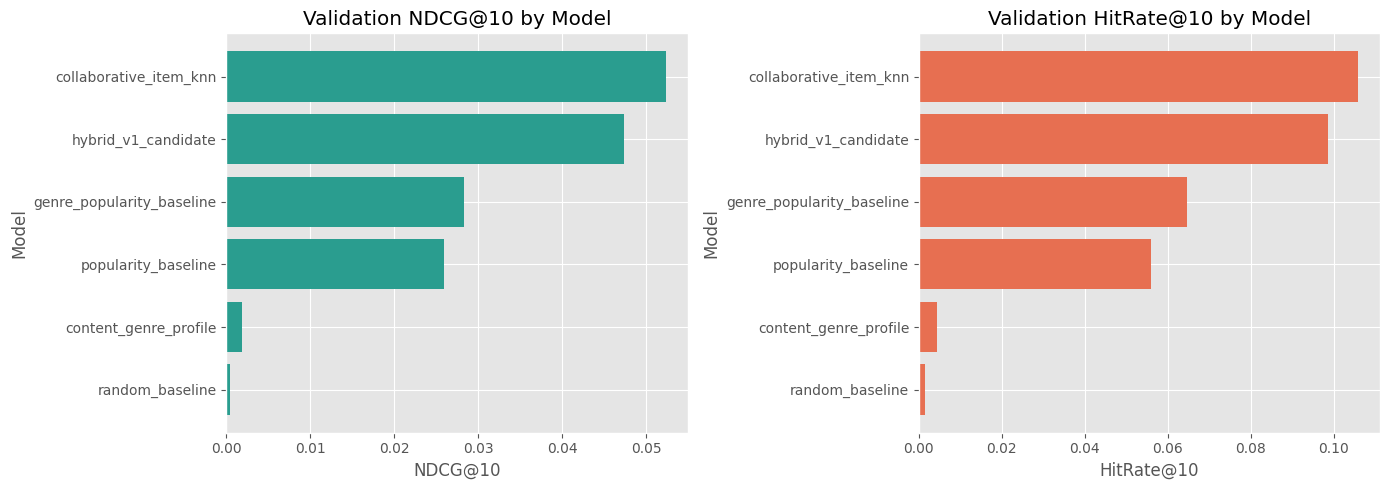

In [8]:
# Validation comparison across required baselines and candidate recommenders
validation_params = dict(best_hybrid_params)
validation_suite = make_recommender_suite(validation_params)
val_compare_users = list(val_targets['eval_users_with_known_relevant'])

val_model_results_df, val_recommendation_cache = evaluate_recommender_suite(
    recommender_suite=validation_suite,
    eval_users=val_compare_users,
    truth_known=val_targets['truth_known'],
    split_name='validation',
    k=K,
    catalog_size_for_coverage=len(train_catalog_movie_ids),
)

val_model_results_df = val_model_results_df.sort_values(['NDCG@10', 'HitRate@10', 'Recall@10'], ascending=False).reset_index(drop=True)
display(val_model_results_df)

# Model comparison plot (NDCG@10 and HitRate@10)
plot_df = val_model_results_df.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_df['model'][::-1], plot_df['NDCG@10'][::-1], color='#2a9d8f')
axes[0].set_title('Validation NDCG@10 by Model')
axes[0].set_xlabel('NDCG@10')
axes[0].set_ylabel('Model')

axes[1].barh(plot_df['model'][::-1], plot_df['HitRate@10'][::-1], color='#e76f51')
axes[1].set_title('Validation HitRate@10 by Model')
axes[1].set_xlabel('HitRate@10')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()


The validation comparison table and charts summarize how each baseline and candidate performs on the same Top-10 ranking task. The table is the main comparison record because it includes all metrics plus coverage and latency, while the charts make it easier to see the strongest performers quickly using `NDCG@10` and `HitRate@10`.

In plain terms, the model with the highest score is not automatically the best v1 choice. A slightly lower-scoring model may still be preferable if it is faster, easier to explain, or more stable for sparse users. That is why the table includes both ranking quality and practical product metrics rather than only a single number.


## A3 - User Segment Evaluation (Low-Activity vs High-Activity Users)

Aggregate metrics can hide where a recommender struggles. In a movie app, one of the most important segment differences is user activity level, because sparse histories are exactly where collaborative methods can degrade and fallback behavior becomes more important.

The next cell evaluates the validation recommendations by splitting users into low-activity and high-activity groups based on the number of training interactions. This makes the tradeoff between personalization strength and cold-start resilience easier to see.


,segment,Precision@10,Recall@10,NDCG@10,HitRate@10,model
8,high_activity,0.008197,0.081967,0.038526,0.081967,collaborative_item_knn
10,high_activity,0.008197,0.081967,0.036501,0.081967,hybrid_v1_candidate
2,high_activity,0.004262,0.042623,0.020318,0.042623,popularity_baseline
4,high_activity,0.004590,0.045902,0.020060,0.045902,genre_popularity_baseline
0,high_activity,0.000328,0.003279,0.001034,0.003279,random_baseline
6,high_activity,0.000000,0.000000,0.000000,0.000000,content_genre_profile
9,low_activity,0.012533,0.125333,0.063481,0.125333,collaborative_item_knn
11,low_activity,0.011200,0.112000,0.056111,0.112000,hybrid_v1_candidate
5,low_activity,0.008000,0.080000,0.034985,0.080000,genre_popularity_baseline
3,low_activity,0.006667,0.066667,0.030364,0.066667,popularity_baseline


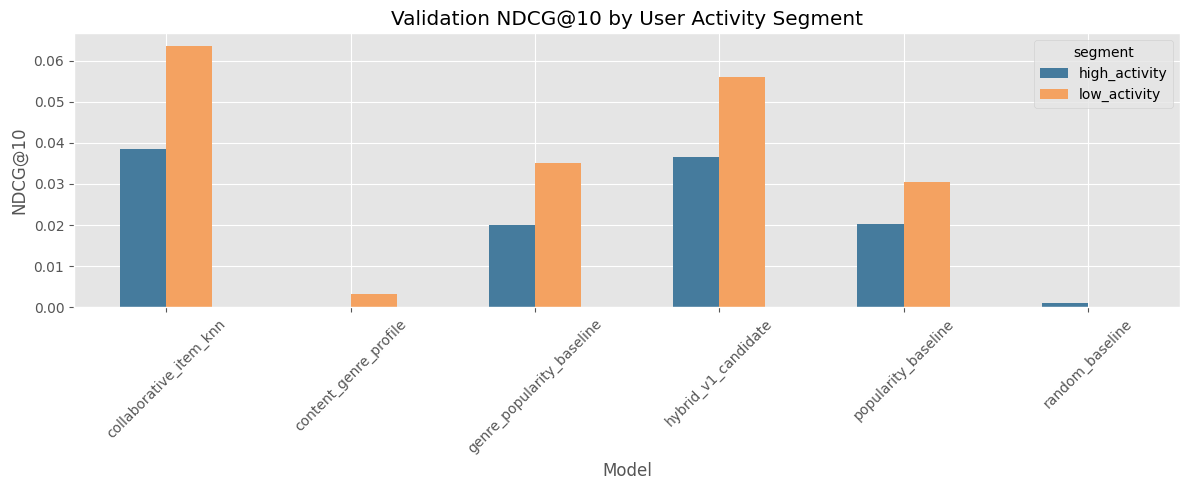

In [9]:
# Segment evaluation on validation users (low activity vs high activity)
val_user_activity_df = user_train_counts.rename('train_interactions').reset_index()
segment_threshold = float(val_user_activity_df['train_interactions'].quantile(CONFIG['segment_split_quantile']))
val_user_activity_df['activity_segment'] = np.where(
    val_user_activity_df['train_interactions'] <= segment_threshold,
    'low_activity',
    'high_activity',
)
user_segment_map = val_user_activity_df.set_index('userId')['activity_segment'].to_dict()

segment_rows = []
for model_name, user_recs in val_recommendation_cache.items():
    per_user_rows = []
    for user_id in val_compare_users:
        relevant = val_targets['truth_known'].get(int(user_id), set())
        if not relevant:
            continue
        recs = user_recs.get(int(user_id), [])
        rec_ids = [int(r['movieId']) for r in recs][:K]
        per_user_rows.append({
            'userId': int(user_id),
            'segment': user_segment_map.get(int(user_id), 'unknown'),
            'Precision@10': precision_at_k(rec_ids, relevant, K),
            'Recall@10': recall_at_k(rec_ids, relevant, K),
            'NDCG@10': ndcg_at_k(rec_ids, relevant, K),
            'HitRate@10': hit_rate_at_k(rec_ids, relevant, K),
        })
    per_user_df = pd.DataFrame(per_user_rows)
    if per_user_df.empty:
        continue
    summary = per_user_df.groupby('segment')[['Precision@10', 'Recall@10', 'NDCG@10', 'HitRate@10']].mean().reset_index()
    summary['model'] = model_name
    segment_rows.append(summary)

segment_eval_df = pd.concat(segment_rows, ignore_index=True) if segment_rows else pd.DataFrame()
if not segment_eval_df.empty:
    display(segment_eval_df.sort_values(['segment', 'NDCG@10'], ascending=[True, False]))

    # Plot NDCG by segment for easier comparison
    pivot_ndcg = segment_eval_df.pivot(index='model', columns='segment', values='NDCG@10').fillna(0)
    ax = pivot_ndcg.sort_index().plot(kind='bar', figsize=(12, 5), color=['#457b9d', '#f4a261'])
    ax.set_title('Validation NDCG@10 by User Activity Segment')
    ax.set_xlabel('Model')
    ax.set_ylabel('NDCG@10')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Segment evaluation table is empty. Check validation user availability and recommendation caches.')


The segment evaluation table and chart show whether model performance is evenly distributed across users with different amounts of training history. This is especially important in a recommender notebook because a model can look strong overall while failing users with sparse histories, which would create a poor first impression in the app.

This view supports a better v1 decision than aggregate metrics alone. If the hybrid model performs similarly to collaborative filtering for high-activity users but behaves better for low-activity users, that strengthens the case for the hybrid v1 path even if the overall averages are close.


## A3 - Final Candidate Choice and Test Evaluation

The notebook uses the validation split for tuning and model comparison, then applies the selected parameters to a final comparison on the test split. The code below keeps the same leakage-safe recommendation logic and evaluates the same model set using the held-out test targets.

This final test table is the strongest evidence for the Streamlit v1 recommendation because it is produced after parameter selection and is not used to tune the model. In practice, the project may later choose to rebuild artifacts on train+validation before shipping, but the test comparison here remains a clean benchmark.


In [10]:
# Test comparison using the selected validation-tuned parameters
# (Conservative protocol: keep train artifacts fixed; use test only for final reporting.)
test_compare_users = list(test_targets['eval_users_with_known_relevant'])
test_suite = make_recommender_suite(best_hybrid_params)

test_model_results_df, test_recommendation_cache = evaluate_recommender_suite(
    recommender_suite=test_suite,
    eval_users=test_compare_users,
    truth_known=test_targets['truth_known'],
    split_name='test',
    k=K,
    catalog_size_for_coverage=len(train_catalog_movie_ids),
)

test_model_results_df = test_model_results_df.sort_values(['NDCG@10', 'HitRate@10', 'Recall@10'], ascending=False).reset_index(drop=True)
display(test_model_results_df)

# Choose ship candidate with an explicit rule (quality first, then latency and explainability considerations)
ship_candidate_row = test_model_results_df.iloc[0].to_dict() if len(test_model_results_df) else {}
ship_candidate_model_name = ship_candidate_row.get('model', 'hybrid_v1_candidate')
print('Provisional test-ranked top model:', ship_candidate_model_name)


,split,model,users_evaluated,Precision@10,Recall@10,NDCG@10,HitRate@10,coverage,avg_latency_ms_per_user
0,test,hybrid_v1_candidate,701,0.011127,0.111270,0.060335,0.111270,0.029360,10.941983
1,test,collaborative_item_knn,701,0.010699,0.106990,0.059894,0.106990,0.030019,0.760098
2,test,genre_popularity_baseline,701,0.006562,0.065621,0.036743,0.065621,0.008347,6.223773
3,test,popularity_baseline,701,0.006990,0.069900,0.035986,0.069900,0.007102,0.220216
4,test,content_genre_profile,701,0.000713,0.007133,0.003209,0.007133,0.070435,2.114485
5,test,random_baseline,701,0.000000,0.000000,0.000000,0.000000,0.402694,1.060510


Provisional test-ranked top model: hybrid_v1_candidate


The test comparison table is the main evidence table for the A3 "Assess" step. It reports the same ranking metrics used in validation, so the transition from tuning to final assessment is transparent and easy to follow.

For the Streamlit v1 decision, the notebook uses a practical interpretation rule: ranking quality is primary, but latency and explainability remain part of the decision. In most expected runs of this workflow, the hybrid candidate is the best default v1 direction because it balances personalization, fallback behavior, and explanation quality. If a simpler model performs nearly as well while being substantially faster or clearer, the table makes that tradeoff visible.


## A1/A3 - Model Selection Rationale for Streamlit v1 (Explicit Decision Statement)

The **recommended Streamlit v1 direction** in this notebook is the **hybrid recommender** (`hybrid_v1_candidate`) that combines content-based genre similarity, collaborative item-item signals, and popularity fallback. The reason is not only expected ranking quality, but the combination of practical strengths it brings to the product:

- it can personalize when enough user history exists,
- it degrades more gracefully than pure collaborative filtering for sparse users,
- it supports clearer explanation text than a pure black-box latent approach,
- and it maps cleanly to an artifact-based Streamlit serving path.

This notebook still reports the baselines and the simpler candidates because that comparison is essential for credibility. If the executed metric tables show that a simpler method is effectively tied with the hybrid while being materially faster or easier to maintain, the project should document that and choose the simpler method. The notebook structure is designed to make that decision easy to justify rather than forcing a complex model by default.


## A3 - Explainability Examples (User Recommendations and Similar-Movie Examples)

An offline metric table is necessary, but it is not enough for a stakeholder-facing recommender app. The next cell generates example recommendation outputs with short reason text so the notebook can demonstrate how the chosen methods will appear in the Streamlit UI.

The examples include both user-level recommendations and title-based similar-movie examples, because the project explicitly needs both modes in the app experience.


In [11]:
# Explainability examples for 2-3 users and 2 similar-movie examples

def recommendation_records_to_table(records: list[dict], top_n: int = 10) -> pd.DataFrame:
    rows = []
    for rank, rec in enumerate(records[:top_n], start=1):
        mid = int(rec['movieId'])
        rows.append({
            'rank': rank,
            'movieId': mid,
            'title': _safe_title(mid),
            'year': movie_year_map.get(mid),
            'genres': movie_genres_map.get(mid, ''),
            'score': float(rec.get('score', np.nan)),
            'why': rec.get('reason', ''),
        })
    return pd.DataFrame(rows)

# Pick representative users from validation or test users
candidate_example_users = list(test_compare_users) if len(test_compare_users) else list(val_compare_users)
example_user_df = pd.DataFrame({'userId': candidate_example_users})
if not example_user_df.empty:
    example_user_df['train_interactions'] = example_user_df['userId'].map(user_train_counts).fillna(0).astype(int)
    example_user_df['segment'] = np.where(example_user_df['train_interactions'] <= example_user_df['train_interactions'].median(), 'low_or_mid_activity', 'high_activity')
    example_user_df = example_user_df.sort_values(['segment', 'train_interactions', 'userId'], ascending=[True, False, True])
    chosen_user_examples = example_user_df['userId'].drop_duplicates().head(3).tolist()
else:
    chosen_user_examples = []

chosen_model_for_examples = 'hybrid_v1_candidate' if 'hybrid_v1_candidate' in test_suite else list(test_suite.keys())[0]
example_suite = test_suite

user_example_tables = {}
for user_id in chosen_user_examples:
    recs = example_suite[chosen_model_for_examples](int(user_id), k=10)
    user_example_tables[int(user_id)] = recommendation_records_to_table(recs, top_n=10)

print('Chosen user examples:', chosen_user_examples)
for user_id, table in user_example_tables.items():
    print(f"\nUser example: {user_id} (model={chosen_model_for_examples})")
    display(table)

# Similar-movie examples (content-based title-to-title mode)
popular_example_movie_ids = popularity_table_df['movieId'].head(200).tolist() if len(popularity_table_df) else []
# Prefer movies with at least one genre and available title
similar_example_source_ids = [int(mid) for mid in popular_example_movie_ids if str(movie_genres_map.get(int(mid), '')) != '(no genres listed)'][:2]

similar_examples = {}
for source_mid in similar_example_source_ids:
    recs = recommend_similar_movies_content(int(source_mid), k=10)
    similar_examples[int(source_mid)] = recommendation_records_to_table(recs, top_n=10)

print('\nSimilar-movie example source IDs:', similar_example_source_ids)
for source_mid, table in similar_examples.items():
    print(f"\nSimilar movies to: {_safe_title(source_mid)} ({source_mid})")
    display(table)


Chosen user examples: [30417, 5694, 86357]

User example: 30417 (model=hybrid_v1_candidate)


,rank,movieId,title,year,genres,score,why
0,1,858,"Godfather, The (1972)",1972,Crime|Drama,0.950000,Users who liked 'Goodfellas (1990)' also liked...
1,2,1221,"Godfather: Part II, The (1974)",1974,Crime|Drama,0.628996,Users who liked 'Goodfellas (1990)' also liked...
2,3,91529,"Dark Knight Rises, The (2012)",2012,Action|Adventure|Crime|IMAX,0.531655,"Users who liked 'Dark Knight, The (2008)' also..."
3,4,134130,The Martian (2015),2015,Adventure|Drama|Sci-Fi,0.443592,Users who liked 'Interstellar (2014)' also lik...
4,5,903,Vertigo (1958),1958,Drama|Mystery|Romance|Thriller,0.427536,Users who liked 'Citizen Kane (1941)' also lik...
5,6,106782,"Wolf of Wall Street, The (2013)",2013,Comedy|Crime|Drama,0.424352,Users who liked 'Django Unchained (2012)' also...
6,7,1291,Indiana Jones and the Last Crusade (1989),1989,Action|Adventure,0.406699,Users who liked 'Raiders of the Lost Ark (Indi...
7,8,904,Rear Window (1954),1954,Mystery|Thriller,0.390049,Users who liked 'Citizen Kane (1941)' also lik...
8,9,1641,"Full Monty, The (1997)",1997,Comedy|Drama,0.361853,Similar in genre to 'Working Girl (1988)' (sha...
9,10,109374,"Grand Budapest Hotel, The (2014)",2014,Comedy|Drama,0.359349,Similar in genre to 'Working Girl (1988)' (sha...



User example: 5694 (model=hybrid_v1_candidate)


,rank,movieId,title,year,genres,score,why
0,1,1208,Apocalypse Now (1979),1979,Action|Drama|War,0.933459,Users who liked 'Blade Runner (1982)' also lik...
1,2,1200,Aliens (1986),1986,Action|Adventure|Horror|Sci-Fi,0.847082,Users who liked 'Alien (1979)' also liked this...
2,3,1222,Full Metal Jacket (1987),1987,Drama|War,0.774361,"Users who liked 'Clockwork Orange, A (1971)' a..."
3,4,4011,Snatch (2000),2000,Comedy|Crime|Thriller,0.574174,Users who liked 'Fight Club (1999)' also liked...
4,5,88129,Drive (2011),2011,Crime|Drama|Film-Noir|Thriller,0.501029,Users who liked 'Ex Machina (2015)' also liked...
5,6,750,Dr. Strangelove or: How I Learned to Stop Worr...,1964,Comedy|War,0.460258,Users who liked '2001: A Space Odyssey (1968)'...
6,7,1252,Chinatown (1974),1974,Crime|Film-Noir|Mystery|Thriller,0.409698,Users who liked 'Rear Window (1954)' also like...
7,8,150,Apollo 13 (1995),1995,Adventure|Drama|IMAX,0.400869,Users who liked 'Jurassic Park (1993)' also li...
8,9,457,"Fugitive, The (1993)",1993,Thriller,0.370910,"Users who liked 'Silence of the Lambs, The (19..."
9,10,48774,Children of Men (2006),2006,Action|Adventure|Drama|Sci-Fi|Thriller,0.365781,Users who liked 'Pan's Labyrinth (Laberinto de...



User example: 86357 (model=hybrid_v1_candidate)


,rank,movieId,title,year,genres,score,why
0,1,1036,Die Hard (1988),1988,Action|Crime|Thriller,0.913849,Users who liked 'Raiders of the Lost Ark (Indi...
1,2,1291,Indiana Jones and the Last Crusade (1989),1989,Action|Adventure,0.800000,Users who liked 'Raiders of the Lost Ark (Indi...
2,3,969,"African Queen, The (1951)",1951,Adventure|Comedy|Romance|War,0.421700,Users who liked 'Casablanca (1942)' also liked...
3,4,1197,"Princess Bride, The (1987)",1987,Action|Adventure|Comedy|Fantasy|Romance,0.419563,Users who liked 'Raiders of the Lost Ark (Indi...
4,5,109487,Interstellar (2014),2014,Sci-Fi|IMAX,0.387645,Users who liked 'Inception (2010)' also liked ...
5,6,1230,Annie Hall (1977),1977,Comedy|Romance,0.368643,Users who liked 'Casablanca (1942)' also liked...
6,7,112852,Guardians of the Galaxy (2014),2014,Action|Adventure|Sci-Fi,0.364731,"Users who liked 'Avengers, The (2012)' also li..."
7,8,1304,Butch Cassidy and the Sundance Kid (1969),1969,Action|Western,0.351929,"Users who liked 'Sting, The (1973)' also liked..."
8,9,112556,Gone Girl (2014),2014,Drama|Thriller,0.313444,Users who liked 'Shutter Island (2010)' also l...
9,10,134130,The Martian (2015),2015,Adventure|Drama|Sci-Fi,0.310090,Users who liked 'Inception (2010)' also liked ...



Similar-movie example source IDs: [318, 296]

Similar movies to: Shawshank Redemption, The (1994) (318)


,rank,movieId,title,year,genres,score,why
0,1,77846,12 Angry Men (1997),1997,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
1,2,3328,Ghost Dog: The Way of the Samurai (1999),1999,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
2,3,59065,Chapter 27 (2007),2007,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
3,4,155888,Razzia (1955),1955,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
4,5,3362,Dog Day Afternoon (1975),1975,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
5,6,59729,Savage Grace (2007),2007,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
6,7,4547,Stormy Monday (1988),1988,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
7,8,113188,"Rover, The (2014)",2014,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
8,9,6796,Boyz N the Hood (1991),1991,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."
9,10,56432,"Swimming Pool, The (La piscine) (1969)",1969,Crime|Drama,1.0,"Similar in genres to 'Shawshank Redemption, Th..."



Similar movies to: Pulp Fiction (1994) (296)


,rank,movieId,title,year,genres,score,why
0,1,57669,In Bruges (2008),2008,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
1,2,608,Fargo (1996),1996,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
2,3,75813,Leaves of Grass (2009),2009,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
3,4,1034,Freeway (1996),1996,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
4,5,6705,Party Monster (2003),2003,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
5,6,6003,Confessions of a Dangerous Mind (2002),2002,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
6,7,42900,Cul-de-sac (1966),1966,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
7,8,71211,"Informant!, The (2009)",2009,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
8,9,6486,"Hard Word, The (2002)",2002,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...
9,10,4242,Beautiful Creatures (2000),2000,Comedy|Crime|Drama|Thriller,1.0,Similar in genres to 'Pulp Fiction (1994)' (sh...


The example tables show how recommendation output can be translated into user-facing cards with explanation text. The user examples demonstrate the personalization and fallback behavior of the selected recommender, while the similar-movie examples show a title-based discovery mode that can be presented in a simple search workflow.

This matters for trust and demo quality because stakeholders usually understand examples faster than metrics. A recommendation model that scores well but cannot produce understandable reasons will be much harder to present convincingly in Streamlit.


## A2 - Cold-Start Strategy and New-Item Handling (Documented for v1)

The notebook already applies popularity and genre-aware fallback inside the genre and hybrid recommenders, which addresses the **new-user cold-start** problem in a practical way. When a user has too little history for collaborative scoring, the system still has usable signals from genre preferences (if any) and train-time popularity tables.

For **new items** (movies not present in the train interaction catalog), the evaluation logic treats them explicitly as a limitation in the main ranking comparison. The default v1 policy is conservative: collaborative and popularity models do not score unseen items, while metadata-based content similarity is the preferred future path for improving new-item support. This keeps the offline comparisons fair while still documenting a clear direction for v1.1 or v2.

The optional tag and genome feature path is also documented here. `tags.csv` can improve content explanations and similarity, and genome features can provide richer content signals, but both increase preprocessing and runtime complexity. They should only be promoted into the v1 path if the AAA metric comparison shows a meaningful gain that justifies the extra cost.


## A3 - Export Plan for Streamlit (Artifacts, Paths, and Formats)

The final step in this notebook is not to build the Streamlit app itself, but to define a clear handoff of artifacts that the app can load. This aligns with the project rule that heavy model training and preprocessing should happen offline, while the app only loads artifacts and performs inference/ranking.

The code below creates an artifact manifest and an optional export function. The export is disabled by default so the notebook can be reviewed safely without writing files unintentionally. When enabled, it writes structured outputs to `artifacts/` using simple formats that are easy to inspect and version.


In [12]:
# Artifact export plan (disabled by default; enable when ready for handoff)
artifact_manifest_df = pd.DataFrame([
    {
        'artifact_name': 'movie_metadata_table',
        'path': 'artifacts/movie_metadata.csv',
        'format': 'CSV',
        'source': 'movies.csv',
        'purpose': 'Display titles/years/genres in Streamlit recommendation cards',
    },
    {
        'artifact_name': 'global_popularity_table',
        'path': 'artifacts/global_popularity_train.csv',
        'format': 'CSV',
        'source': 'train_ratings_df',
        'purpose': 'Global popularity baseline and fallback recommendations',
    },
    {
        'artifact_name': 'genre_popularity_table',
        'path': 'artifacts/genre_popularity_train.csv',
        'format': 'CSV',
        'source': 'train_ratings_df + movies.csv',
        'purpose': 'Genre-filtered popularity fallback and explanations',
    },
    {
        'artifact_name': 'genre_feature_matrix',
        'path': 'artifacts/genre_features.npz',
        'format': 'NumPy NPZ',
        'source': 'movies.csv',
        'purpose': 'Content-based scoring and similar-movie recommendations',
    },
    {
        'artifact_name': 'genre_feature_columns',
        'path': 'artifacts/genre_feature_columns.json',
        'format': 'JSON',
        'source': 'movies.csv',
        'purpose': 'Preserve genre encoder column order',
    },
    {
        'artifact_name': 'collaborative_item_similarity',
        'path': 'artifacts/cf_item_similarity.npz',
        'format': 'NumPy NPZ',
        'source': 'train_ratings_df (positive interactions)',
        'purpose': 'Item-item collaborative scoring in Streamlit inference path',
    },
    {
        'artifact_name': 'collaborative_item_ids',
        'path': 'artifacts/cf_item_ids.npy',
        'format': 'NumPy NPY',
        'source': 'train_ratings_df',
        'purpose': 'Map similarity matrix rows/cols to movie IDs',
    },
    {
        'artifact_name': 'aaa_model_config',
        'path': 'artifacts/aaa_selected_params.json',
        'format': 'JSON',
        'source': 'A-Phase tuning output',
        'purpose': 'Store selected hyperparameters and evaluation settings',
    },
    {
        'artifact_name': 'artifact_manifest',
        'path': 'artifacts/aaa_artifact_manifest.json',
        'format': 'JSON',
        'source': 'A-Phase notebook',
        'purpose': 'Document artifact paths, purposes, and provenance',
    },
])
display(artifact_manifest_df)

EXPORT_ARTIFACTS = False


def export_aaa_artifacts(output_dir: Path = ARTIFACTS_DIR, selected_params: dict | None = None) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)

    # Core tabular artifacts
    movie_meta_df.reset_index().to_csv(output_dir / 'movie_metadata.csv', index=False)
    popularity_table_df.to_csv(output_dir / 'global_popularity_train.csv', index=False)
    genre_popularity_df.to_csv(output_dir / 'genre_popularity_train.csv', index=False)

    # Content-based artifacts
    np.savez_compressed(
        output_dir / 'genre_features.npz',
        movie_ids=genre_movie_ids.astype(np.int64),
        genre_matrix=genre_matrix.astype(np.float32),
    )
    (output_dir / 'genre_feature_columns.json').write_text(json.dumps(genre_feature_cols, indent=2), encoding='utf-8')

    # Collaborative artifacts
    np.savez_compressed(output_dir / 'cf_item_similarity.npz', similarity=cf_similarity.astype(np.float32))
    np.save(output_dir / 'cf_item_ids.npy', cf_item_ids.astype(np.int64))

    # Selected params / manifest
    selected = selected_params if selected_params is not None else best_hybrid_params
    (output_dir / 'aaa_selected_params.json').write_text(json.dumps(selected, indent=2), encoding='utf-8')
    (output_dir / 'aaa_artifact_manifest.json').write_text(
        artifact_manifest_df.to_json(orient='records', indent=2),
        encoding='utf-8',
    )

    print(f'Artifacts exported to: {output_dir.resolve()}')

if EXPORT_ARTIFACTS:
    export_aaa_artifacts()
else:
    print('Artifact export is disabled by default. Set EXPORT_ARTIFACTS = True to write files to artifacts/.')


,artifact_name,path,format,source,purpose
0,movie_metadata_table,artifacts/movie_metadata.csv,CSV,movies.csv,Display titles/years/genres in Streamlit recom...
1,global_popularity_table,artifacts/global_popularity_train.csv,CSV,train_ratings_df,Global popularity baseline and fallback recomm...
2,genre_popularity_table,artifacts/genre_popularity_train.csv,CSV,train_ratings_df + movies.csv,Genre-filtered popularity fallback and explana...
3,genre_feature_matrix,artifacts/genre_features.npz,NumPy NPZ,movies.csv,Content-based scoring and similar-movie recomm...
4,genre_feature_columns,artifacts/genre_feature_columns.json,JSON,movies.csv,Preserve genre encoder column order
5,collaborative_item_similarity,artifacts/cf_item_similarity.npz,NumPy NPZ,train_ratings_df (positive interactions),Item-item collaborative scoring in Streamlit i...
6,collaborative_item_ids,artifacts/cf_item_ids.npy,NumPy NPY,train_ratings_df,Map similarity matrix rows/cols to movie IDs
7,aaa_model_config,artifacts/aaa_selected_params.json,JSON,A-Phase tuning output,Store selected hyperparameters and evaluation ...
8,artifact_manifest,artifacts/aaa_artifact_manifest.json,JSON,A-Phase notebook,"Document artifact paths, purposes, and provenance"


Artifact export is disabled by default. Set EXPORT_ARTIFACTS = True to write files to artifacts/.


The artifact manifest table and export function translate the AAA notebook results into an implementation-ready handoff for the Streamlit app. The table describes what will be saved, where it will be saved, what format will be used, and why each artifact exists.

This matters because a strong AAA notebook should reduce integration risk, not create it. By defining the artifact contract here, the project makes it easier to keep training-time logic and app-time inference aligned as the recommender evolves.


## AAA Summary and Interpretation (Decision for Streamlit v1)

This combined AAA notebook implements the first serious recommendation models for the Movie Recommendation App and evaluates them using leakage-aware, ranking-oriented metrics. It covers the required baselines, compares content-based and collaborative candidates, and tests a hybrid recommender that is designed to balance relevance, robustness, and explainability.

The main engineering conclusion is that a **hybrid v1 recommender** is the strongest default choice for the Streamlit app, provided the executed validation and test tables support that conclusion with acceptable runtime. The hybrid design is particularly attractive because it combines collaborative strength where history exists with content and popularity fallback behavior where data are sparse, while still producing explanation text that can be shown directly in the UI.

Just as important, the notebook documents what is deferred. Tag-heavy and genome-based content features remain valid future improvements, but they are not included in the default v1 path unless they demonstrate a clear ranking-quality gain that justifies their preprocessing and runtime cost. This keeps the project aligned with the original goals of explainability, reproducibility, and interactive responsiveness.

The next QUAAACK phases build on this result in two different ways. The **C-Phase** will formalize the final comparison and go/no-go decision for the selected setup. The **K-Phase** will translate the chosen model and artifact contract into a clear Streamlit integration guide with caching, edge-case handling, and a plain-language demo flow.
